In [1]:
import numpy as np
import xarray as xr


# ============================================================
# SETTINGS
# ============================================================

ERA5_FILE = "ERA5_daily_GEV_parameters_1981_2024.nc"

IFS_LOCATION_FILE = "IFS_UNSEEN_GEV_Fidelity_DailyBiasCorrected/IFS_UNSEEN_GEV_location.nc"
IFS_SCALE_FILE    = "IFS_UNSEEN_GEV_Fidelity_DailyBiasCorrected/IFS_UNSEEN_GEV_scale.nc"
IFS_SHAPE_FILE    = "IFS_UNSEEN_GEV_Fidelity_DailyBiasCorrected/IFS_UNSEEN_GEV_shape.nc"

OUTPUT_FILE = "ERA5_IFS_daily_GEV_fidelity_1981_2024_dailycorrected.nc"

LOW_PERCENTILE = 5.0
HIGH_PERCENTILE = 95.0


# ============================================================
# 1. Open files
# ============================================================

print("=" * 70)
print("Opening files")
print("=" * 70)

era5 = xr.open_dataset(ERA5_FILE)

ifs_loc = xr.open_dataset(IFS_LOCATION_FILE)
ifs_scale = xr.open_dataset(IFS_SCALE_FILE)
ifs_shape = xr.open_dataset(IFS_SHAPE_FILE)


print("\nERA5:")
print(era5)

print("\nIFS location:")
print(ifs_loc)

print("\nIFS scale:")
print(ifs_scale)

print("\nIFS shape:")
print(ifs_shape)


# ============================================================
# 2. Basic checks
# ============================================================

print("\n")
print("=" * 70)
print("Checking region IDs")
print("=" * 70)


era5_regions = era5["region_id"].values

loc_regions = ifs_loc["region_id"].values
scale_regions = ifs_scale["region_id"].values
shape_regions = ifs_shape["region_id"].values


if not np.array_equal(
    era5_regions,
    loc_regions,
):
    raise ValueError(
        "ERA5 and IFS location region IDs do not match."
    )


if not np.array_equal(
    era5_regions,
    scale_regions,
):
    raise ValueError(
        "ERA5 and IFS scale region IDs do not match."
    )


if not np.array_equal(
    era5_regions,
    shape_regions,
):
    raise ValueError(
        "ERA5 and IFS shape region IDs do not match."
    )


nregion = len(era5_regions)

print(
    f"Region IDs match: {nregion} regions"
)


# ============================================================
# 3. Extract ERA5 parameters
# ============================================================

era5_location = era5["location"]
era5_scale = era5["scale"]
era5_shape = era5["shape"]


# ============================================================
# 4. Extract IFS bootstrap distributions
# ============================================================

ifs_location = ifs_loc["location"]
ifs_scale_da = ifs_scale["scale"]
ifs_shape_da = ifs_shape["shape"]


# ============================================================
# 5. Calculate 5th and 95th percentiles
#
# skipna=True:
#
# If occasional bootstrap fits failed and were stored as NaN,
# they are ignored when calculating the distribution limits.
# ============================================================

print("\n")
print("=" * 70)
print(
    f"Calculating {LOW_PERCENTILE:.0f}th-"
    f"{HIGH_PERCENTILE:.0f}th percentile ranges"
)
print("=" * 70)


location_low = ifs_location.quantile(
    LOW_PERCENTILE / 100.0,
    dim="bootstrap",
    skipna=True,
)

location_high = ifs_location.quantile(
    HIGH_PERCENTILE / 100.0,
    dim="bootstrap",
    skipna=True,
)


scale_low = ifs_scale_da.quantile(
    LOW_PERCENTILE / 100.0,
    dim="bootstrap",
    skipna=True,
)

scale_high = ifs_scale_da.quantile(
    HIGH_PERCENTILE / 100.0,
    dim="bootstrap",
    skipna=True,
)


shape_low = ifs_shape_da.quantile(
    LOW_PERCENTILE / 100.0,
    dim="bootstrap",
    skipna=True,
)

shape_high = ifs_shape_da.quantile(
    HIGH_PERCENTILE / 100.0,
    dim="bootstrap",
    skipna=True,
)


# Remove scalar quantile coordinate if present

for da in [
    location_low,
    location_high,
    scale_low,
    scale_high,
    shape_low,
    shape_high,
]:
    if "quantile" in da.coords:
        da.coords["quantile"] = float(
            da.coords["quantile"]
        )


# ============================================================
# 6. Fidelity test for each parameter
#
# Inclusive boundaries:
#
#     P5 <= ERA5 <= P95
#
# counts as PASS.
# ============================================================

print("\nPerforming fidelity tests...")


location_pass = (
    (era5_location >= location_low)
    &
    (era5_location <= location_high)
)


scale_pass = (
    (era5_scale >= scale_low)
    &
    (era5_scale <= scale_high)
)


shape_pass = (
    (era5_shape >= shape_low)
    &
    (era5_shape <= shape_high)
)


# ============================================================
# 7. Check invalid / missing values
#
# A region cannot pass if ERA5 parameter or percentile
# threshold is missing.
# ============================================================

location_valid = (
    np.isfinite(era5_location)
    &
    np.isfinite(location_low)
    &
    np.isfinite(location_high)
)


scale_valid = (
    np.isfinite(era5_scale)
    &
    np.isfinite(scale_low)
    &
    np.isfinite(scale_high)
)


shape_valid = (
    np.isfinite(era5_shape)
    &
    np.isfinite(shape_low)
    &
    np.isfinite(shape_high)
)


location_pass = (
    location_pass & location_valid
)

scale_pass = (
    scale_pass & scale_valid
)

shape_pass = (
    shape_pass & shape_valid
)


# ============================================================
# 8. Number of failed parameters
# ============================================================

location_fail = ~location_pass
scale_fail = ~scale_pass
shape_fail = ~shape_pass


n_failed = (
    location_fail.astype(np.int8)
    +
    shape_fail.astype(np.int8)
    +
    scale_fail.astype(np.int8)
)


# ============================================================
# 9. Fidelity score
#
# Definition:
#
# 4 = all three pass
#
# 3 = location only fails
#
# 2 = shape only fails
#
# 1 = scale only fails
#
# 0 = two or three parameters fail
# ============================================================

score = xr.full_like(
    era5_location,
    0,
    dtype=np.int8,
)


# All pass

score = xr.where(
    location_pass
    &
    shape_pass
    &
    scale_pass,
    4,
    score,
)


# Only location fails

score = xr.where(
    location_fail
    &
    shape_pass
    &
    scale_pass,
    1,
    score,
)


# Only shape fails

score = xr.where(
    location_pass
    &
    shape_fail
    &
    scale_pass,
    3,
    score,
)


# Only scale fails

score = xr.where(
    location_pass
    &
    shape_pass
    &
    scale_fail,
    2,
    score,
)


score.name = "fidelity_score"


# ============================================================
# 10. Create output Dataset
# ============================================================

ds_out = xr.Dataset(

    data_vars={

        # ----------------------------------------------------
        # Final fidelity classification
        # ----------------------------------------------------

        "fidelity_score": (
            ("region_id",),
            score.values.astype(np.int8),
        ),

        "n_failed_parameters": (
            ("region_id",),
            n_failed.values.astype(np.int8),
        ),


        # ----------------------------------------------------
        # Individual parameter pass/fail
        #
        # 1 = pass
        # 0 = fail
        # ----------------------------------------------------

        "location_pass": (
            ("region_id",),
            location_pass.values.astype(np.int8),
        ),

        "shape_pass": (
            ("region_id",),
            shape_pass.values.astype(np.int8),
        ),

        "scale_pass": (
            ("region_id",),
            scale_pass.values.astype(np.int8),
        ),


        # ----------------------------------------------------
        # ERA5 fitted parameters
        # ----------------------------------------------------

        "ERA5_location": (
            ("region_id",),
            era5_location.values.astype(np.float32),
        ),

        "ERA5_shape": (
            ("region_id",),
            era5_shape.values.astype(np.float32),
        ),

        "ERA5_scale": (
            ("region_id",),
            era5_scale.values.astype(np.float32),
        ),


        # ----------------------------------------------------
        # IFS bootstrap 5th percentile
        # ----------------------------------------------------

        "IFS_location_p05": (
            ("region_id",),
            location_low.values.astype(np.float32),
        ),

        "IFS_shape_p05": (
            ("region_id",),
            shape_low.values.astype(np.float32),
        ),

        "IFS_scale_p05": (
            ("region_id",),
            scale_low.values.astype(np.float32),
        ),


        # ----------------------------------------------------
        # IFS bootstrap 95th percentile
        # ----------------------------------------------------

        "IFS_location_p95": (
            ("region_id",),
            location_high.values.astype(np.float32),
        ),

        "IFS_shape_p95": (
            ("region_id",),
            shape_high.values.astype(np.float32),
        ),

        "IFS_scale_p95": (
            ("region_id",),
            scale_high.values.astype(np.float32),
        ),

    },

    coords={

        "region_id":
            era5_regions.astype(np.int16),

    },

)


# ============================================================
# 11. Metadata
# ============================================================

ds_out["fidelity_score"].attrs = {

    "long_name":
        "GEV fidelity score",

    "description":
        (
            "4 = location, shape and scale all pass; "
            "3 = only shape fails; "
            "2 = only scale fails; "
            "1 = only location fails; "
            "0 = two or more parameters fail."
        ),

}


ds_out["n_failed_parameters"].attrs = {

    "long_name":
        "Number of GEV parameters failing fidelity test",

}


for var in [
    "location_pass",
    "shape_pass",
    "scale_pass",
]:

    ds_out[var].attrs = {

        "description":
            (
                "1 = ERA5 parameter lies within "
                "the IFS bootstrap 5th-95th "
                "percentile interval; "
                "0 = outside interval."
            )

    }


ds_out["ERA5_location"].attrs = {
    "long_name": "ERA5 GEV location parameter",
    "units": "K",
}

ds_out["ERA5_scale"].attrs = {
    "long_name": "ERA5 GEV scale parameter",
    "units": "K",
}

ds_out["ERA5_shape"].attrs = {
    "long_name": "ERA5 GEV shape parameter xi",
    "units": "1",
}


ds_out.attrs = {

    "title":
        "ERA5 versus IFS daily GEV fidelity test",

    "ERA5_period":
        "1981-2024",

    "IFS_bootstrap_repetitions":
        10000,

    "fidelity_interval":
        "5th-95th percentile",

    "fidelity_definition":
        (
            "An individual GEV parameter passes when "
            "the ERA5 fitted parameter lies within "
            "the inclusive 5th-95th percentile interval "
            "of the corresponding IFS UNSEEN bootstrap "
            "distribution."
        ),

    "score_definition":
        (
            "4=all parameters pass; "
            "3=location only fails; "
            "2=shape only fails; "
            "1=scale only fails; "
            "0=two or more parameters fail."
        ),

    "shape_convention":
        "xi",

}


# ============================================================
# 12. Summary
# ============================================================

print("\n")
print("=" * 70)
print("FIDELITY SUMMARY")
print("=" * 70)


scores = ds_out["fidelity_score"].values


for s in [4, 3, 2, 1, 0]:

    count = int(
        np.sum(scores == s)
    )

    percentage = (
        count / nregion * 100.0
    )

    print(
        f"Score {s}: "
        f"{count:3d} / {nregion} "
        f"({percentage:5.1f}%)"
    )


print("\nIndividual parameter pass rates:")


for name in [
    "location",
    "shape",
    "scale",
]:

    passed = int(
        ds_out[
            f"{name}_pass"
        ].sum().values
    )

    percentage = (
        passed / nregion * 100.0
    )

    print(
        f"{name:8s}: "
        f"{passed:3d} / {nregion} "
        f"({percentage:5.1f}%)"
    )


# ============================================================
# 13. Check classification consistency
# ============================================================

print("\nChecking score consistency...")


# score 4 must have zero failures
assert np.all(
    ds_out["n_failed_parameters"]
    .where(
        ds_out.fidelity_score == 4,
        drop=True,
    )
    .values
    == 0
)


# score 1/2/3 must have exactly one failure
single_failure_scores = (
    (scores == 1)
    |
    (scores == 2)
    |
    (scores == 3)
)


assert np.all(
    ds_out[
        "n_failed_parameters"
    ].values[
        single_failure_scores
    ]
    == 1
)


# score 0 must have >= 2 failures
assert np.all(
    ds_out[
        "n_failed_parameters"
    ].values[
        scores == 0
    ]
    >= 2
)


print("Classification consistency: PASSED")


# ============================================================
# 14. Save NetCDF
# ============================================================

print("\nWriting:")
print(OUTPUT_FILE)


encoding = {}


for var in ds_out.data_vars:

    if ds_out[var].dtype == np.float32:

        encoding[var] = {
            "dtype": "float32",
            "zlib": True,
            "complevel": 4,
        }

    elif ds_out[var].dtype == np.int8:

        encoding[var] = {
            "dtype": "int8",
            "zlib": True,
            "complevel": 4,
        }


ds_out.to_netcdf(
    OUTPUT_FILE,
    format="NETCDF4",
    encoding=encoding,
)


print("\n")
print("=" * 70)
print("FINISHED")
print("=" * 70)

print("\nOutput:")
print(OUTPUT_FILE)

print("\nDataset:")
print(ds_out)


# ============================================================
# 15. Close input files
# ============================================================

era5.close()
ifs_loc.close()
ifs_scale.close()
ifs_shape.close()

Opening files

ERA5:
<xarray.Dataset> Size: 5kB
Dimensions:      (region_id: 237)
Coordinates:
  * region_id    (region_id) int16 474B 0 1 2 3 4 5 ... 231 232 233 234 235 236
Data variables:
    location     (region_id) float32 948B ...
    scale        (region_id) float32 948B ...
    shape        (region_id) float32 948B ...
    scipy_shape  (region_id) float32 948B ...
    sample_size  (region_id) int16 474B ...
Attributes:
    title:             GEV parameters fitted to pooled ERA5 daily hottest-mon...
    analysis_period:   1981-2024
    method:            For each region, all finite daily regional mean temper...
    shape_convention:  shape is the conventional GEV xi parameter; shape = -s...

IFS location:
<xarray.Dataset> Size: 10MB
Dimensions:      (region_id: 237, bootstrap: 10000)
Coordinates:
  * region_id    (region_id) int16 474B 0 1 2 3 4 5 ... 231 232 233 234 235 236
  * bootstrap    (bootstrap) int32 40kB 1 2 3 4 5 ... 9996 9997 9998 9999 10000
Data variables:
    locat

<xarray.Dataset> Size: 10kB
Dimensions:              (region_id: 237)
Coordinates:
  * region_id            (region_id) int16 474B 0 1 2 3 4 ... 233 234 235 236
Data variables: (12/14)
    fidelity_score       (region_id) int8 237B ...
    n_failed_parameters  (region_id) int8 237B ...
    location_pass        (region_id) int8 237B ...
    shape_pass           (region_id) int8 237B ...
    scale_pass           (region_id) int8 237B ...
    ERA5_location        (region_id) float32 948B ...
    ...                   ...
    IFS_location_p05     (region_id) float32 948B ...
    IFS_shape_p05        (region_id) float32 948B ...
    IFS_scale_p05        (region_id) float32 948B ...
    IFS_location_p95     (region_id) float32 948B ...
    IFS_shape_p95        (region_id) float32 948B ...
    IFS_scale_p95        (region_id) float32 948B ...
Attributes:
    title:                      ERA5 versus IFS daily GEV fidelity test
    ERA5_period:                1981-2024
    IFS_bootstrap_repetiti

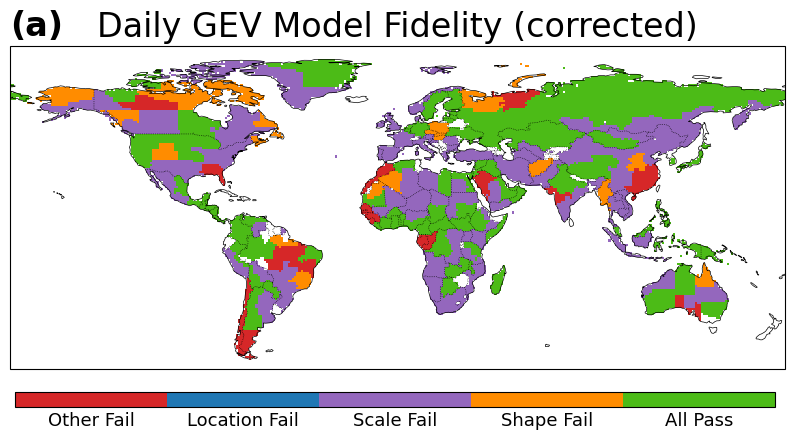

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# 1. FILES
# ============================================================

FIDELITY_FILE = (
    "ERA5_IFS_daily_GEV_fidelity_1981_2024_dailycorrected.nc"
)

REGION_FILE = (
    "/home/users/kastanie/"
    "Global_regional_analysis/"
    "atmos-WRAF01-v4-1/"
    "region_mask_1deg.nc"
)

OUTPUT_FILE = (
    "IFS_Daily_GEV_Parameters_Fidelity_DetailMap.pdf"
)


# ============================================================
# 2. READ DATA
# ============================================================

ds_fidelity = xr.open_dataset(FIDELITY_FILE)

region_ds = xr.open_dataset(REGION_FILE)

print(ds_fidelity)


# ============================================================
# 3. READ FIDELITY SCORE
#
# Old definition:
#
# 0 = multiple failures / other
# 1 = location fail only
# 2 = scale fail only
# 3 = shape fail only
# 4 = all pass
# ============================================================

scores = ds_fidelity["fidelity_score"]

region_ids = ds_fidelity["region_id"].values


# ============================================================
# 4. PRINT SUMMARY
# ============================================================

print("\n======================================")
print("GEV Fidelity Test Summary")
print("======================================")

labels = {
    0: "Other / multiple fail",
    1: "Location only fail",
    2: "Scale only fail",
    3: "Shape only fail",
    4: "All pass",
}

n_regions = len(region_ids)


for score in range(5):

    n = int(
        (scores == score).sum().values
    )

    print(
        f"{labels[score]:22s}: "
        f"{n:3d} "
        f"({100 * n / n_regions:5.1f}%)"
    )


# ============================================================
# 5. MAP REGION SCORES BACK TO GRID
# ============================================================

region_grid = region_ds["region_id"]


score_grid = xr.full_like(
    region_grid,
    np.nan,
    dtype=float,
)


for rid in region_ids:

    score = float(
        scores.sel(region_id=rid).values
    )

    score_grid = score_grid.where(
        region_grid != rid,
        score,
    )


# ============================================================
# 6. COLORMAP
#
# Keep exactly the same colours as the old figure
# ============================================================

cmap = mcolors.ListedColormap([

    "#d62728",   # 0: Other / multiple failure

    "#1f77b4",   # 1: Location fail

    "#9467bd",   # 2: Scale fail

    "#ff8c00",   # 3: Shape fail

    "#4cbb17",   # 4: All pass

])


norm = mcolors.BoundaryNorm(

    [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5],

    cmap.N,

)


# ============================================================
# 7. PLOT
# ============================================================

fig = plt.figure(
    figsize=(10, 5)
)


ax = fig.add_subplot(
    1,
    1,
    1,
    projection=ccrs.PlateCarree(),
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(
    "Daily GEV Model Fidelity (corrected)",
    fontsize=24,
)


# ------------------------------------------------------------
# Coastlines / borders
# ------------------------------------------------------------

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.5,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    linestyle=":",
)


# ------------------------------------------------------------
# Map extent
# ------------------------------------------------------------

ax.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree(),
)


# ------------------------------------------------------------
# Panel label
# ------------------------------------------------------------

ax.text(
    0.0,
    1.03,
    "(a)",
    transform=ax.transAxes,
    fontsize=24,
    ha="left",
    fontweight="bold",
)


# ------------------------------------------------------------
# Map
# ------------------------------------------------------------

im = ax.pcolormesh(

    region_ds.longitude,

    region_ds.latitude,

    score_grid,

    shading="auto",

    cmap=cmap,

    norm=norm,

    transform=ccrs.PlateCarree(),

)


# ============================================================
# 8. COLORBAR
# ============================================================

cbar_ax = fig.add_axes(
    [0.13, 0.095, 0.76, 0.03]
)


cbar = fig.colorbar(

    im,

    cax=cbar_ax,

    orientation="horizontal",

    ticks=[0, 1, 2, 3, 4],

)


cbar.ax.set_xticklabels([

    "Other Fail",

    "Location Fail",

    "Scale Fail",

    "Shape Fail",

    "All Pass",

])


cbar.ax.tick_params(
    which="both",
    length=0,
    labelsize=13,
)


# ============================================================
# 9. SAVE
# ============================================================

plt.savefig(

    OUTPUT_FILE,

    dpi=300,

    bbox_inches="tight",

)


plt.show()


# ============================================================
# 10. CLOSE
# ============================================================

ds_fidelity.close()
region_ds.close()

DAILY
<xarray.Dataset> Size: 10kB
Dimensions:              (region_id: 237)
Coordinates:
  * region_id            (region_id) int16 474B 0 1 2 3 4 ... 233 234 235 236
Data variables: (12/14)
    fidelity_score       (region_id) int8 237B ...
    n_failed_parameters  (region_id) int8 237B ...
    location_pass        (region_id) int8 237B ...
    shape_pass           (region_id) int8 237B ...
    scale_pass           (region_id) int8 237B ...
    ERA5_location        (region_id) float32 948B ...
    ...                   ...
    IFS_location_p05     (region_id) float32 948B ...
    IFS_shape_p05        (region_id) float32 948B ...
    IFS_scale_p05        (region_id) float32 948B ...
    IFS_location_p95     (region_id) float32 948B ...
    IFS_shape_p95        (region_id) float32 948B ...
    IFS_scale_p95        (region_id) float32 948B ...
Attributes:
    title:                      ERA5 versus IFS daily GEV fidelity test
    ERA5_period:                1981-2024
    IFS_bootstrap_re

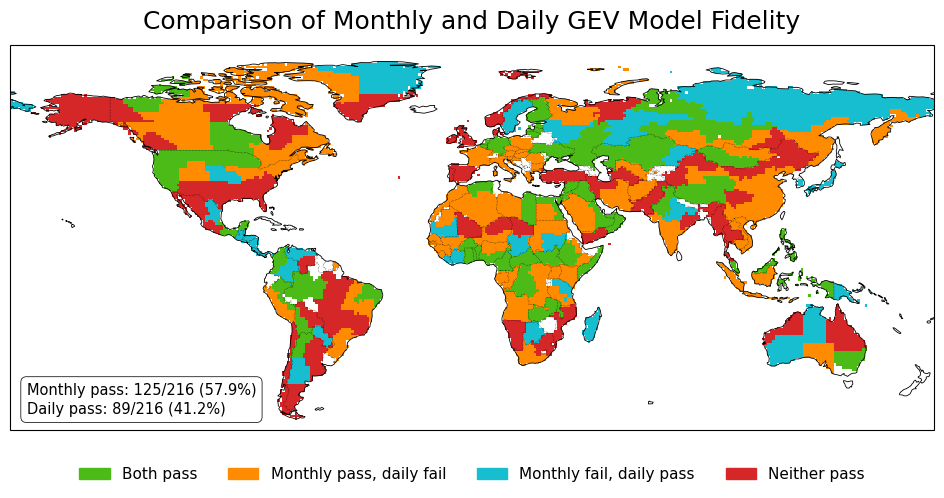

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# 1. FILE PATHS
# ============================================================

DAILY_FILE = (
    "ERA5_IFS_daily_GEV_fidelity_1981_2024_dailycorrected.nc"
)

MONTHLY_FILE = (
    "/home/users/kastanie/"
    "Global_regional_analysis/"
    "atmos-WRAF01-v4-1/"
    "hottestmonth/"
    "IFS_GEV_Parameters_Fidelity_DetailMap.nc"
)

REGION_FILE = (
    "/home/users/kastanie/"
    "Global_regional_analysis/"
    "atmos-WRAF01-v4-1/"
    "region_mask_1deg.nc"
)

OUTPUT_FILE = (
    "Daily_vs_Monthly_GEV_Fidelity_Comparison_dailycorrected.pdf"
)


# ============================================================
# 2. SETTINGS
# ============================================================

# Only regions occurring north of 60°S are included
# in the statistical denominator.
LATITUDE_CUTOFF = -60.0


# ============================================================
# 3. OPEN DATA
# ============================================================

ds_daily = xr.open_dataset(DAILY_FILE)

ds_monthly = xr.open_dataset(MONTHLY_FILE)

ds_region = xr.open_dataset(REGION_FILE)


print("=" * 70)
print("DAILY")
print("=" * 70)
print(ds_daily)

print("\n")
print("=" * 70)
print("MONTHLY")
print("=" * 70)
print(ds_monthly)

print("\n")
print("=" * 70)
print("REGION MASK")
print("=" * 70)
print(ds_region)


# ============================================================
# 4. EXTRACT VARIABLES
# ============================================================

daily_score = ds_daily["fidelity_score"]

monthly_grid = ds_monthly["fidelity"]

region_grid = ds_region["region_id"]


# ============================================================
# 5. CHECK MONTHLY GRID AND REGION GRID
# ============================================================

print("\n")
print("=" * 70)
print("CHECKING GRIDS")
print("=" * 70)


# Dimension sizes

if monthly_grid.sizes["latitude"] != region_grid.sizes["latitude"]:
    raise ValueError(
        "Monthly fidelity and region mask latitude sizes differ."
    )

if monthly_grid.sizes["longitude"] != region_grid.sizes["longitude"]:
    raise ValueError(
        "Monthly fidelity and region mask longitude sizes differ."
    )


# Coordinates

if not np.allclose(
    monthly_grid["latitude"].values,
    region_grid["latitude"].values,
):
    raise ValueError(
        "Monthly fidelity and region mask latitude coordinates differ."
    )


if not np.allclose(
    monthly_grid["longitude"].values,
    region_grid["longitude"].values,
):
    raise ValueError(
        "Monthly fidelity and region mask longitude coordinates differ."
    )


print(
    "Monthly fidelity grid matches region mask exactly."
)


# ============================================================
# 6. DAILY REGION IDs
# ============================================================

region_ids = ds_daily["region_id"].values

nregion = len(region_ids)


print("\nNumber of all regions:", nregion)

print(
    "Region IDs:",
    int(region_ids.min()),
    "to",
    int(region_ids.max()),
)


# ============================================================
# 7. IDENTIFY REGIONS NORTH OF 60°S
#
# The statistical denominator should not include Antarctica.
#
# A region is retained if at least one grid cell belonging to
# that region occurs at latitude >= 60°S.
#
# This avoids hard-coding Antarctic region IDs.
# ============================================================

print("\n")
print("=" * 70)
print("IDENTIFYING NON-ANTARCTIC REGIONS")
print("=" * 70)


# Keep only grid cells north of / at 60°S

region_grid_north = region_grid.where(
    region_grid["latitude"] >= LATITUDE_CUTOFF,
    drop=True,
)


# Extract region IDs appearing north of 60°S

north_values = region_grid_north.values

north_values = north_values[
    np.isfinite(north_values)
]


north_region_ids = np.unique(
    north_values
).astype(region_ids.dtype)


# Boolean mask corresponding to the ordering of
# region_ids in the daily dataset

non_antarctic_mask = np.isin(
    region_ids,
    north_region_ids,
)


# Number of regions actually used for statistics

nregion_stats = int(
    np.sum(non_antarctic_mask)
)


# Regions excluded from statistics

antarctic_region_ids = region_ids[
    ~non_antarctic_mask
]


print(
    f"Latitude cutoff: {LATITUDE_CUTOFF:.1f}°"
)

print(
    f"Total regions: {nregion}"
)

print(
    f"Regions north of 60°S: {nregion_stats}"
)

print(
    f"Regions excluded as Antarctic: "
    f"{nregion - nregion_stats}"
)

print(
    "Excluded region IDs:",
    antarctic_region_ids,
)


if nregion_stats == 0:
    raise ValueError(
        "No regions were found north of 60°S. "
        "Please check the latitude coordinates."
    )


# ============================================================
# 8. CONVERT MONTHLY SPATIAL MAP
#    TO MONTHLY SCORE(region_id)
#
# For each region:
#
# region_mask == rid
#
# then find the fidelity value inside that region.
#
# Ideally every grid cell belonging to the same region
# should have exactly the same monthly fidelity score.
# ============================================================

print("\n")
print("=" * 70)
print("CONVERTING MONTHLY MAP TO REGION SCORES")
print("=" * 70)


monthly_region_score = np.full(
    nregion,
    np.nan,
    dtype=float,
)


for i, rid in enumerate(region_ids):

    # Spatial mask for this region

    mask = (
        region_grid.values == rid
    )


    # Monthly fidelity values inside region

    values = monthly_grid.values[mask]


    # Remove NaN

    values = values[
        np.isfinite(values)
    ]


    if len(values) == 0:

        print(
            f"WARNING: region {rid} "
            "has no valid monthly fidelity value."
        )

        continue


    # Unique fidelity values

    unique_values = np.unique(values)


    if len(unique_values) > 1:

        print(
            f"WARNING: region {rid} contains "
            f"multiple monthly fidelity values: "
            f"{unique_values}"
        )


    # Since monthly fidelity should be constant
    # within each region, use the most common value.

    vals, counts = np.unique(
        values,
        return_counts=True,
    )

    monthly_region_score[i] = vals[
        np.argmax(counts)
    ]


# ============================================================
# 9. DAILY SCORES
# ============================================================

daily_region_score = (
    daily_score
    .sel(region_id=region_ids)
    .values
)


# ============================================================
# 10. PRINT DAILY / MONTHLY SCORE CHECK
# ============================================================

print("\n")
print("=" * 70)
print("REGIONAL SCORE CHECK")
print("=" * 70)


for i in range(min(10, nregion)):

    print(
        f"Region {int(region_ids[i]):3d} | "
        f"Monthly = {monthly_region_score[i]:.0f} | "
        f"Daily = {daily_region_score[i]:.0f}"
    )


# ============================================================
# 11. DEFINE PASS / FAIL
# ============================================================

monthly_pass = (
    monthly_region_score == 4
)


# Keep your current daily definition:
# score == 4 OR score == 1 is treated as passing.

daily_pass = (
    (daily_region_score == 4) |
    (daily_region_score == 1)
)


# If you later want STRICT score == 4 only,
# replace the block above with:
#
# daily_pass = (
#     daily_region_score == 4
# )


# ============================================================
# 12. CLASSIFICATION
#
# 0 = neither passes
#
# 1 = monthly passes
#     daily fails
#
# 2 = monthly fails
#     daily passes
#
# 3 = both pass
# ============================================================

comparison = np.full(
    nregion,
    np.nan,
    dtype=float,
)


# Neither passes

comparison[
    (~monthly_pass) &
    (~daily_pass)
] = 0


# Monthly passes, daily fails

comparison[
    monthly_pass &
    (~daily_pass)
] = 1


# Monthly fails, daily passes

comparison[
    (~monthly_pass) &
    daily_pass
] = 2


# Both pass

comparison[
    monthly_pass &
    daily_pass
] = 3


# ============================================================
# 13. PRINT CLASSIFICATION SUMMARY
#
# IMPORTANT:
# Statistics now use ONLY regions north of 60°S.
# Antarctica is excluded from both numerator and denominator.
# ============================================================

print("\n")
print("=" * 70)
print("DAILY vs MONTHLY FIDELITY")
print("Statistics exclude Antarctica (<60°S)")
print("=" * 70)


labels = {

    0: "Neither pass",

    1: "Monthly pass -> Daily fail",

    2: "Monthly fail -> Daily pass",

    3: "Both pass",

}


for category in range(4):

    n = int(
        np.sum(
            (comparison == category) &
            non_antarctic_mask
        )
    )

    percentage = (
        n / nregion_stats * 100
    )

    print(
        f"{labels[category]:28s}: "
        f"{n:3d} / {nregion_stats} "
        f"({percentage:5.1f}%)"
    )


# ============================================================
# 14. MONTHLY / DAILY PASS STATISTICS
#
# Again, only use regions north of 60°S.
# ============================================================

n_monthly_pass = int(
    np.sum(
        monthly_pass &
        non_antarctic_mask
    )
)


n_daily_pass = int(
    np.sum(
        daily_pass &
        non_antarctic_mask
    )
)


monthly_percentage = (
    100.0 *
    n_monthly_pass /
    nregion_stats
)


daily_percentage = (
    100.0 *
    n_daily_pass /
    nregion_stats
)


print("\n--------------------------------------")

print(
    f"Monthly score = 4 : "
    f"{n_monthly_pass}/{nregion_stats} "
    f"({monthly_percentage:.1f}%)"
)

print(
    f"Daily score = 4   : "
    f"{n_daily_pass}/{nregion_stats} "
    f"({daily_percentage:.1f}%)"
)

print("--------------------------------------")


# Text to be added to the lower-left corner of the map

statistics_text = (
    f"Monthly pass: "
    f"{n_monthly_pass}/{nregion_stats} "
    f"({monthly_percentage:.1f}%)\n"
    f"Daily pass: "
    f"{n_daily_pass}/{nregion_stats} "
    f"({daily_percentage:.1f}%)"
)


# ============================================================
# 15. MAP COMPARISON BACK TO LAT/LON GRID
# ============================================================

comparison_grid = xr.full_like(
    region_grid,
    np.nan,
    dtype=float,
)


for i, rid in enumerate(region_ids):

    comparison_grid = comparison_grid.where(
        region_grid != rid,
        comparison[i],
    )


# ============================================================
# 16. COLORMAP
#
# 0 = red
#     neither monthly nor daily passes
#
# 1 = orange
#     monthly passes, daily fails
#
# 2 = cyan
#     monthly fails, daily passes
#
# 3 = green
#     both pass
# ============================================================

cmap = mcolors.ListedColormap([

    "#d62728",   # red

    "#ff8c00",   # orange

    "#17becf",   # cyan

    "#4cbb17",   # green

])


norm = mcolors.BoundaryNorm(

    [-0.5, 0.5, 1.5, 2.5, 3.5],

    cmap.N,

)


# ============================================================
# 17. PLOT
# ============================================================

fig = plt.figure(
    figsize=(12, 5.5)
)


ax = fig.add_subplot(
    1,
    1,
    1,
    projection=ccrs.PlateCarree(),
)


# ------------------------------------------------------------
# Plot regional classification
# ------------------------------------------------------------

im = ax.pcolormesh(

    ds_region["longitude"],

    ds_region["latitude"],

    comparison_grid,

    cmap=cmap,

    norm=norm,

    shading="auto",

    transform=ccrs.PlateCarree(),

)


# ------------------------------------------------------------
# Coastlines
# ------------------------------------------------------------

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.6,
)


# ------------------------------------------------------------
# National borders
# ------------------------------------------------------------

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.4,
    linestyle=":",
)


# ------------------------------------------------------------
# Extent
#
# Antarctica is not displayed.
# ------------------------------------------------------------

ax.set_extent(

    [-180, 180, -60, 90],

    crs=ccrs.PlateCarree(),

)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.set_title(

    "Comparison of Monthly and Daily GEV Model Fidelity",

    fontsize=18,

    pad=12,

)


# ============================================================
# 18. STATISTICS TEXT BOX
#
# Dynamic values based only on regions north of 60°S.
# Positioned in the lower-left corner of the map.
# ============================================================

ax.text(

    0.018,
    0.035,

    statistics_text,

    transform=ax.transAxes,

    fontsize=10.5,

    ha="left",
    va="bottom",

    linespacing=1.35,

    zorder=10,

    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.88,
    ),

)


# ============================================================
# 19. LEGEND
# ============================================================

legend_handles = [

    mpatches.Patch(
        color="#4cbb17",
        label="Both pass"
    ),

    mpatches.Patch(
        color="#ff8c00",
        label="Monthly pass, daily fail"
    ),

    mpatches.Patch(
        color="#17becf",
        label="Monthly fail, daily pass"
    ),

    mpatches.Patch(
        color="#d62728",
        label="Neither pass"
    ),

]


ax.legend(

    handles=legend_handles,

    loc="lower center",

    bbox_to_anchor=(0.5, -0.17),

    ncol=4,

    frameon=False,

    fontsize=11,

)


# ============================================================
# 20. LAYOUT
# ============================================================

plt.subplots_adjust(
    bottom=0.18
)


# ============================================================
# 21. SAVE
# ============================================================

plt.savefig(

    OUTPUT_FILE,

    dpi=300,

    bbox_inches="tight",

)


print("\nSaved:")
print(OUTPUT_FILE)


plt.show()


# ============================================================
# 22. CLOSE
# ============================================================

ds_daily.close()

ds_monthly.close()

ds_region.close()